# Wine Style Clustering — 01: Exploratory Data Analysis

**Data:** `data/raw/wines_clean_llm.csv` — cleaned and LLM-denoised  
**Goal:** Understand the corpus before modelling — distributions, geography, scores, text quality

---

## 0. Setup

In [32]:
import os
os.chdir(os.path.expanduser('~/Documents/wine-style-clustering'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.spines.top':  False,
    'axes.spines.right': False,
    'font.size': 12,
})

RED  = '#8B1A2A'
WHITE = '#C9A84C'
ROSE  = '#E8A0A0'
GRAY  = '#888888'

print('Ready.')


Ready.


## 1. Load data

In [33]:
df = pd.read_csv('data/raw/wines_clean_llm.csv')
df['desc_len'] = df['description_clean'].fillna(df['description']).str.split().str.len()

print(f'Total reviews: {len(df):,}')
print(f'Columns:       {df.columns.tolist()}')
df.head(3)


Total reviews: 23,266
Columns:       ['url', 'title', 'description', 'score', 'Producer', 'Vintage', 'Wine Type', 'Colour', 'Country', 'Region', 'Appellation', 'Sweetness', 'Closure', 'Alcohol', 'Body', 'Oak', 'Grapes', 'description_clean', 'grape_normalized', 'desc_len', 'oak_normalized']


,url,title,description,score,Producer,Vintage,Wine Type,Colour,Country,Region,...,Sweetness,Closure,Alcohol,Body,Oak,Grapes,description_clean,grape_normalized,desc_len,oak_normalized
0,https://www.decanter.com/wine-reviews/italy/pi...,"Mauro Veglio, Barolo Arborina, La Morra, Piedm...","The estate’s first single-site bottling, in 19...",93.0,Mauro Veglio,2022.0,Still,Red,Italy,Piedmont,...,Dry,Cork,14.50%,Full,Yes,100% Nebbiolo,"It opens sumptuously with cinnamon, tobacco, s...",nebbiolo,53,oaked
1,https://www.decanter.com/wine-reviews/italy/pi...,"Fratelli Alessandria, Barolo Gramolere, Monfor...",Pristine fruit and a clear expression of place...,94.0,Fratelli Alessandria,2022.0,Still,Red,Italy,Piedmont,...,Dry,Cork,14.50%,Full,Oaked,100% Nebbiolo,Pristine fruit and a clear expression of place...,nebbiolo,49,oaked
2,https://www.decanter.com/wine-reviews/italy/pi...,"Ettore Germano, Barolo Vignarionda, Serralunga...",The Germano family inherited half a hectare in...,93.0,Ettore Germano,2021.0,Still,Red,Italy,Piedmont,...,Dry,Cork,14.00%,Full,Yes,100% Nebbiolo,"Still youthful and buttoned up, it gradually u...",nebbiolo,66,oaked


## 2. Colour breakdown

Red, White and Rosé are included in modelling. Orange is kept in the raw data but excluded.

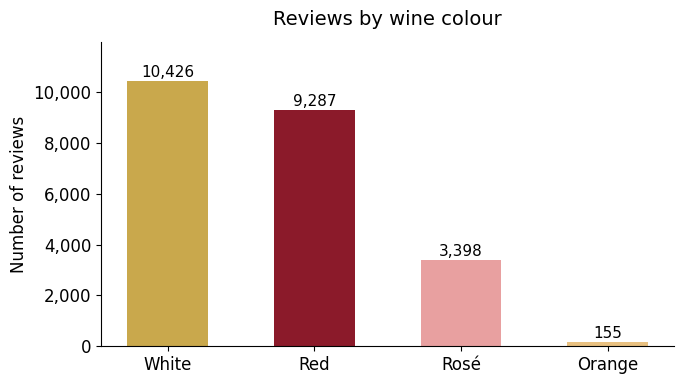

Colour
White     10426
Red        9287
Rosé       3398
Orange      155
Name: count, dtype: int64


In [34]:
colour_counts = df['Colour'].value_counts()
colour_map = {'Red': RED, 'White': WHITE, 'Rosé': ROSE, 'Orange': '#E8C080'}
colors = [colour_map.get(c, GRAY) for c in colour_counts.index]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(colour_counts.index, colour_counts.values, color=colors, width=0.55)
for bar, val in zip(bars, colour_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 40,
            f'{val:,}', ha='center', va='bottom', fontsize=11)
ax.set_title('Reviews by wine colour', fontsize=14, pad=12)
ax.set_ylabel('Number of reviews')
ax.set_ylim(0, colour_counts.max() * 1.15)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig('results/figures/01_colour_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()
print(colour_counts)


## 3. Geographic distribution

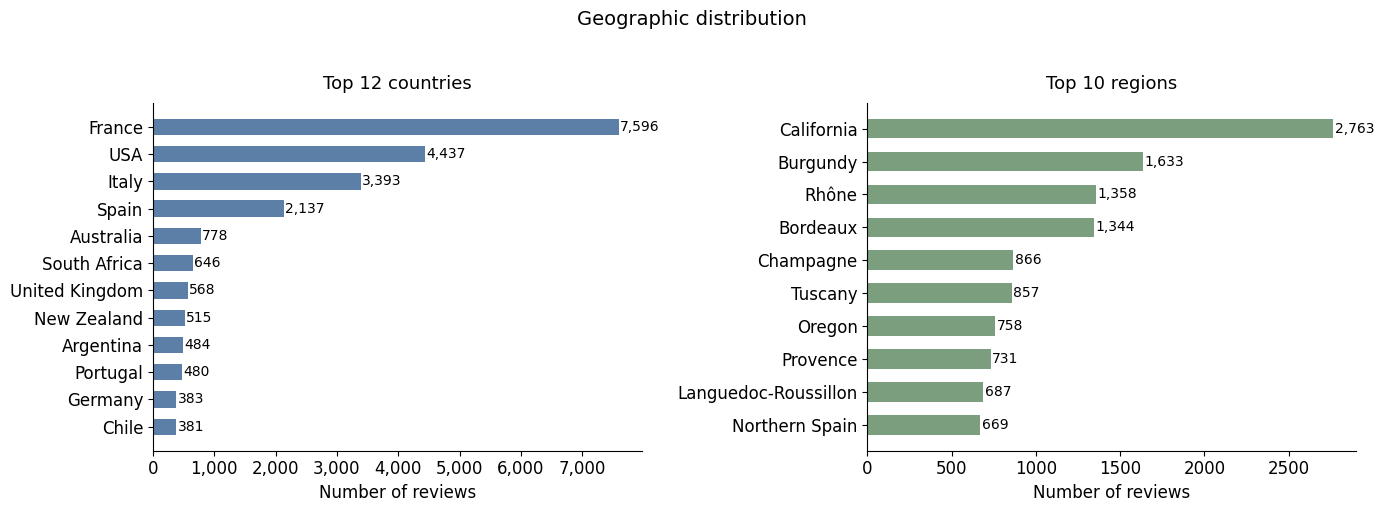

Countries: 54 | Regions: 514


In [35]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

top_countries = df['Country'].value_counts().head(12)
ax1.barh(top_countries.index[::-1], top_countries.values[::-1], color='#5B7FA6', height=0.6)
for i, val in enumerate(top_countries.values[::-1]):
    ax1.text(val + 20, i, f'{val:,}', va='center', fontsize=10)
ax1.set_title('Top 12 countries', fontsize=13, pad=10)
ax1.set_xlabel('Number of reviews')
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

top_regions = df['Region'].value_counts().head(10)
ax2.barh(top_regions.index[::-1], top_regions.values[::-1], color='#7A9E7E', height=0.6)
for i, val in enumerate(top_regions.values[::-1]):
    ax2.text(val + 10, i, f'{val:,}', va='center', fontsize=10)
ax2.set_title('Top 10 regions', fontsize=13, pad=10)
ax2.set_xlabel('Number of reviews')

plt.suptitle('Geographic distribution', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('results/figures/01_geography.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Countries: {df["Country"].nunique()} | Regions: {df["Region"].nunique()}')


## 4. Score distribution

Decanter uses a 100-point scale. Reviews cluster tightly in the 90–96 range.

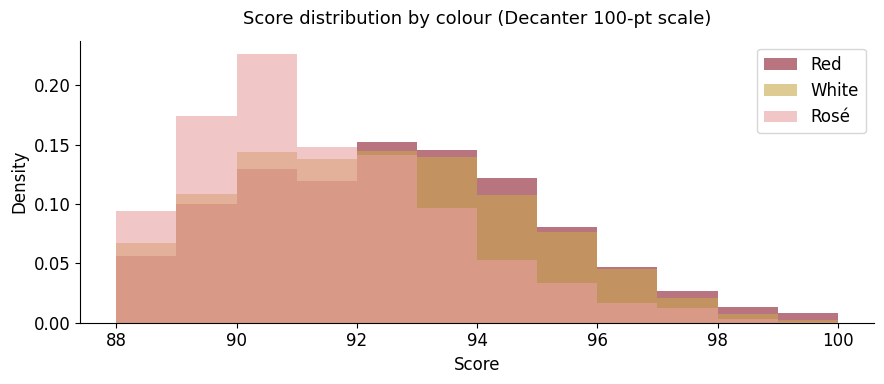

Red    — median: 92.0 | mean: 91.4
White  — median: 92.0 | mean: 91.5
Rosé   — median: 90.0 | mean: 89.7


In [36]:
df_scored = df.dropna(subset=['score'])
df_red    = df_scored[df_scored['Colour'] == 'Red']
df_white  = df_scored[df_scored['Colour'] == 'White']
df_rose   = df_scored[df_scored['Colour'] == 'Rosé']

fig, ax = plt.subplots(figsize=(9, 4))
bins = range(88, 101)
ax.hist(df_red['score'],   bins=bins, color=RED,   alpha=0.6, label='Red',   density=True)
ax.hist(df_white['score'], bins=bins, color=WHITE, alpha=0.6, label='White', density=True)
ax.hist(df_rose['score'],  bins=bins, color=ROSE,  alpha=0.6, label='Rosé',  density=True)
ax.set_title('Score distribution by colour (Decanter 100-pt scale)', fontsize=13, pad=12)
ax.set_xlabel('Score')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.savefig('results/figures/01_score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

for name, sub in [('Red', df_red), ('White', df_white), ('Rosé', df_rose)]:
    print(f'{name:6} — median: {sub["score"].median()} | mean: {sub["score"].mean():.1f}')


## 5. Description length

Very short descriptions (<15 words) are dropped before modelling — not enough signal for embeddings.

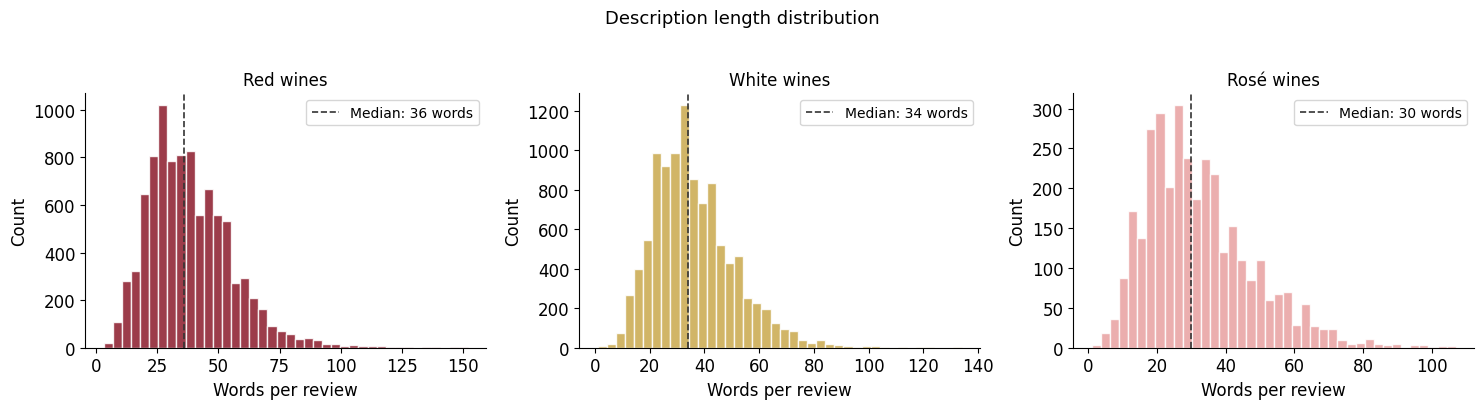

Reviews under 15 words: 1097 (4.7%)


In [37]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, colour, color in zip(axes, ['Red', 'White', 'Rosé'], [RED, WHITE, ROSE]):
    subset = df[df['Colour'] == colour]['desc_len']
    ax.hist(subset, bins=40, color=color, alpha=0.85, edgecolor='white')
    ax.axvline(subset.median(), color='#333', linestyle='--', linewidth=1.2,
               label=f'Median: {subset.median():.0f} words')
    ax.set_title(f'{colour} wines', fontsize=12)
    ax.set_xlabel('Words per review')
    ax.set_ylabel('Count')
    ax.legend(fontsize=10)

plt.suptitle('Description length distribution', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('results/figures/01_desc_length.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Reviews under 15 words: {(df["desc_len"] < 15).sum()} ({(df["desc_len"] < 15).mean()*100:.1f}%)')


## 6. Wine type breakdown

In [38]:
print('Wine types:')
print(df['Wine Type'].value_counts())
print()
print('Modelling subset — Still + Unknown, Red + White + Rosé:')
model = df[
    df['Wine Type'].isin(['Still', 'Unknown']) &
    df['Colour'].isin(['Red', 'White', 'Rosé']) &
    (df['desc_len'] >= 15)
]
print(f'  Total:  {len(model):,}')
print(f'  Red:    {(model["Colour"]=="Red").sum():,}')
print(f'  White:  {(model["Colour"]=="White").sum():,}')
print(f'  Rosé:   {(model["Colour"]=="Rosé").sum():,}')


Wine types:
Wine Type
Still        19942
Sparkling     2721
Unknown        370
Fortified      233
Name: count, dtype: int64

Modelling subset — Still + Unknown, Red + White + Rosé:
  Total:  19,241
  Red:    8,783
  White:  8,364
  Rosé:   2,094


## 7. Grape variety coverage

How well normalised is the `grape_normalized` column after preprocessing?

In [39]:
print('Top 30 grape_normalized:')
print(df['grape_normalized'].value_counts().head(30))
print()
print(f'Unique varieties:   {df["grape_normalized"].nunique()}')
print(f'Null (no info):     {df["grape_normalized"].isna().sum()}')
print(f'Remaining blend:    {(df["grape_normalized"] == "blend").sum()}')


Top 30 grape_normalized:
grape_normalized
chardonnay                  2760
pinot noir                  2226
bordeaux blend              1325
champagne blend             1074
sauvignon blanc              728
riesling                     570
cabernet sauvignon           539
provence blend               515
syrah                        488
rhone blend                  418
sangiovese                   393
grenache                     373
nebbiolo                     360
bordeaux white blend         343
sparkling blend              326
tempranillo                  315
white rhone blend            278
cabernet franc               265
gsm blend                    259
glera                        244
merlot                       232
white blend                  218
valpolicella blend           182
chenin blanc                 178
languedoc blend              178
malbec                       174
grenache blend               174
viognier                     173
rioja blend                  173
c

---

## Summary

| Metric | Value |
|--------|-------|
| Total reviews | 23,266 |
| Red + White + Rosé (for modelling) | ~19,600 |
| Wine types | Still, Sparkling, Fortified |
| Countries | 53 |
| Regions | 467+ |
| Median description length | ~36 words (cleaned) |

**Next:** `00_preprocessing.ipynb` → grape normalisation → `02_embeddings_umap.ipynb`
